# 02 — Google Trends Analysis

## Objective
Use Google Trends data to understand consumer search behaviour for loungewear and pyjama-related terms across UK and US markets. Identify demand trends, seasonality patterns, and geographic opportunity.

## Research Questions
1. Is demand for premium kids/teen loungewear growing or flat?
2. When do consumers search — what does seasonality look like?
3. How does UK search volume compare to US for relevant terms?
4. Which search terms are gaining momentum?

## Method
pytrends library (unofficial Google Trends API wrapper). Data is indexed 0–100 (relative search interest, not absolute volume). Comparisons within a single query are valid; cross-query comparisons require a shared reference term.

---

In [2]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from pytrends.request import TrendReq
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
COLOURS = {
    'primary':   '#2E5FA3',
    'secondary': '#E8A838',
    'accent':    '#C0392B',
    'green':     '#27AE60',
    'purple':    '#8E44AD',
}

# ── pytrends setup ────────────────────────────────────────────────────────────
pytrends = TrendReq(hl='en-GB', tz=0, timeout=(10, 25))

print(f'Ready. Analysis date: {datetime.today().strftime("%d %B %Y")}')

Ready. Analysis date: 26 February 2026


---
## Section 1: UK Demand Trends — 5 Year View

Are searches for premium kids/teen pyjamas and loungewear growing? We compare core terms over 5 years in the UK.

In [4]:
def get_trends(keywords, geo, timeframe='today 5-y', delay=2):
    """
    Fetch Google Trends data for a list of keywords.
    Max 5 keywords per request (Google Trends API limit).
    Returns a DataFrame indexed by date.
    """
    assert len(keywords) <= 5, 'Google Trends allows max 5 keywords per request'
    time.sleep(delay)
    pytrends.build_payload(keywords, geo=geo, timeframe=timeframe)
    df = pytrends.interest_over_time()
    if 'isPartial' in df.columns:
        df = df.drop(columns=['isPartial'])
    return df

### Methodology Note — Term Selection

Initial keyword list included `teen loungewear`, `tween pjs`, `tween pajamas`, 
`tween nightwear`, and `tween loungewear`. All returned near-zero search volume 
in both UK (GB) and US geographies over the 5-year period.

**Interpretation:** Consumers do not use "tween" or "loungewear" as primary 
search language for this product category. Dominant terms are `kids pyjamas` / 
`kids pajamas` and `girls pyjamas` / `girls pajamas`. This has direct 
implications for SEO and paid search strategy — a brand targeting this segment 
should optimise for pyjama/pajama language, not loungewear.

Dropped terms retained in raw data files for reference.

In [5]:
ANCHOR = 'kids pyjamas'

batches_uk = [
    [ANCHOR, 'kids pjs', 'kids nightwear', 'luxury pyjamas', 'girls pyjamas'],
    [ANCHOR, 'kids pajamas', 'luxury pajamas', 'girls pajamas'],
]

all_series = {}

for i, batch in enumerate(batches_uk):
    print(f'Fetching UK batch {i+1}/{len(batches_uk)}: {batch}')
    df_batch = get_trends(batch, geo='GB')
    for col in df_batch.columns:
        if col == ANCHOR:
            all_series[ANCHOR] = df_batch[ANCHOR]
        else:
            all_series[col] = df_batch[col]
    time.sleep(4)

df_uk_final = pd.DataFrame(all_series)
df_uk_final.to_csv('/Users/sewabreiler/Desktop/premium-kidswear-market-analysis/02_search_trends/data/uk_final_terms.csv')

print(f'\nFinal UK terms collected:')
print(df_uk_final.mean().sort_values(ascending=False).round(1).to_string())

Fetching UK batch 1/2: ['kids pyjamas', 'kids pjs', 'kids nightwear', 'luxury pyjamas', 'girls pyjamas']
Fetching UK batch 2/2: ['kids pyjamas', 'kids pajamas', 'luxury pajamas', 'girls pajamas']

Final UK terms collected:
kids pyjamas      27.6
girls pyjamas     26.7
kids pjs          21.0
kids pajamas       8.6
girls pajamas      5.8
luxury pyjamas     1.6
luxury pajamas     0.2
kids nightwear     0.2


### UK Terms Note
- girls pyjamas (26.7) is almost identical to kids pyjamas (27.6) — confirms gender-specific search is just as common as the generic term
- kids pjs (21.0) — abbreviation is heavily used, worth knowing for SEO
- kids pajamas (8.6) — meaningful US spelling crossover in UK searches, probably expats and people who've seen US brands
- luxury pyjamas (1.6) and luxury pajamas (0.2) — very low, meaning consumers aren't searching for premium by using the word "luxury". They find premium brands through other routes (social, editorial, gifting searches)
- kids nightwear (0.2) — need to drop, nobody uses it to search

In [8]:
# US Batch
print('Fetching US data...')
df_us_final = get_trends(
    ['kids pajamas', 'girls pajamas', 'kids pjs', 'luxury pajamas'],
    geo='US'
)
df_us_final.to_csv('/Users/sewabreiler/Desktop/premium-kidswear-market-analysis/02_search_trends/data/us_final_terms.csv')

print('\nFinal US terms:')
print(df_us_final.mean().sort_values(ascending=False).round(1).to_string())

Fetching US data...

Final US terms:
kids pajamas      24.4
girls pajamas     15.5
kids pjs           5.9
luxury pajamas     1.4


# US Terms Note - consistent with the UK data. The pattern holds.

- kids pajamas (24.4) dominant, similar scale to UK's kids pyjamas (27.6) — comparable market size signal
- girls pajamas (15.5) strong — lower ratio to the generic term than UK (56% vs 97%) suggesting UK searches are more gender-specific
- kids pjs (5.9) — present but weaker than UK's 21.0, Americans more likely to spell it out
- luxury pajamas (1.4) — same story as UK, consumers don't search "luxury" to find premium products

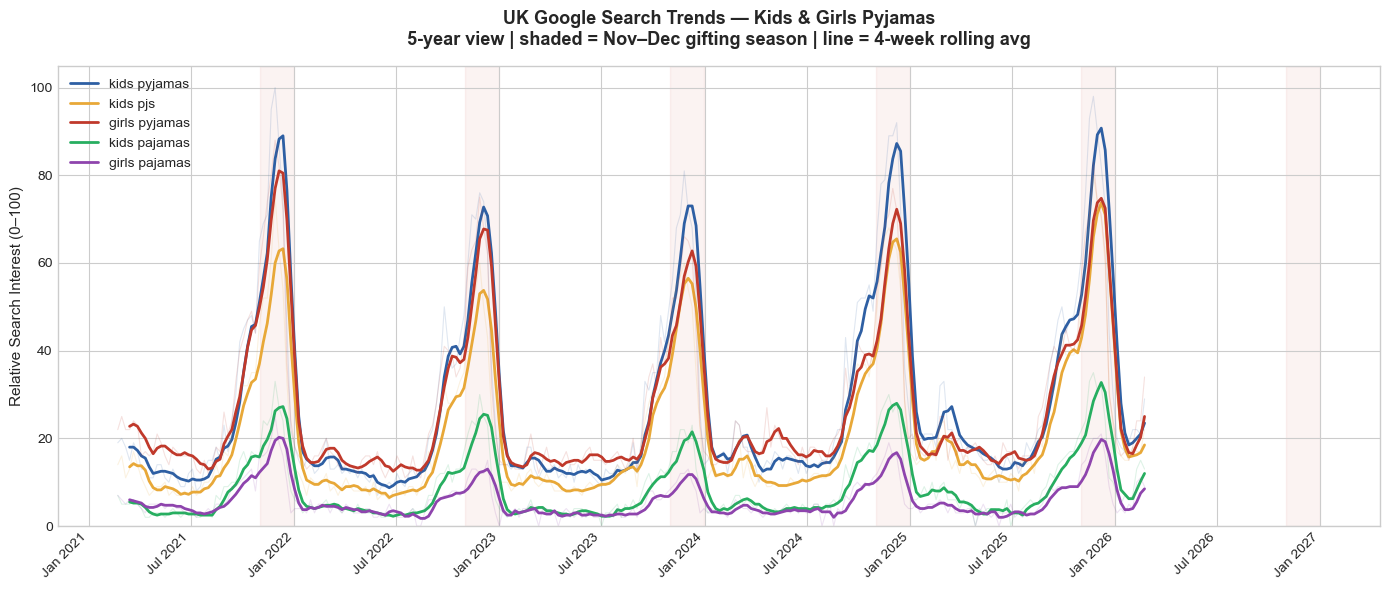

In [11]:
# ── Charts
# Drop near-zero terms before charting
DROP = ['luxury pyjamas', 'luxury pajamas', 'kids nightwear']
df_uk_plot = df_uk_final.drop(columns=[c for c in DROP if c in df_uk_final.columns])

# ── Chart 1: UK trend lines ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

colour_list = list(COLOURS.values())
for i, col in enumerate(df_uk_plot.columns):
    smoothed = df_uk_plot[col].rolling(4).mean()
    ax.plot(df_uk_plot.index, smoothed,
            label=col, color=colour_list[i % len(colour_list)], linewidth=2)
    ax.plot(df_uk_plot.index, df_uk_plot[col],
            color=colour_list[i % len(colour_list)], alpha=0.15, linewidth=0.8)

# Shade Nov-Dec gifting season each year
for year in range(df_uk_plot.index.year.min(), df_uk_plot.index.year.max() + 1):
    ax.axvspan(pd.Timestamp(f'{year}-11-01'),
               pd.Timestamp(f'{year}-12-31'),
               alpha=0.06, color=COLOURS['accent'], zorder=0)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=45, ha='right')
ax.set_ylabel('Relative Search Interest (0–100)', fontsize=11)
ax.set_title('UK Google Search Trends — Kids & Girls Pyjamas\n'
             '5-year view | shaded = Nov–Dec gifting season | line = 4-week rolling avg',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.set_ylim(0)

plt.tight_layout()
plt.savefig('/Users/sewabreiler/Desktop/premium-kidswear-market-analysis/reports/summary_visualisations/02_uk_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()

**Trend lines** — four clean seasonal spikes, all aligning perfectly with Nov–Dec each year. Christmas gifting season dominates completely. kids pyjamas and girls pyjamas tracking almost identically confirms they're essentially the same search intent.

---
## Section 2: Seasonality Analysis

When do consumers search? Understanding seasonality is critical for launch timing and inventory planning.

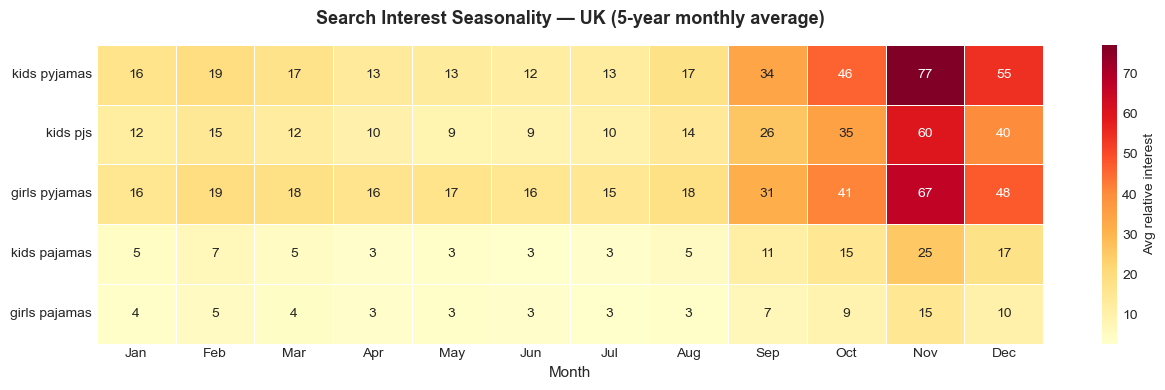

Both charts saved.


In [10]:
# ── Chart 2: Seasonality heatmap ──────────────────────────────────────────────
df_seas = df_uk_plot.copy()
df_seas['month'] = df_seas.index.month
monthly_avg = df_seas.groupby('month')[df_uk_plot.columns].mean()
monthly_avg.index = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(monthly_avg.T, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Avg relative interest'}, ax=ax)
ax.set_xlabel('Month', fontsize=11)
ax.set_title('Search Interest Seasonality — UK (5-year monthly average)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('/Users/sewabreiler/Desktop/premium-kidswear-market-analysis/reports/summary_visualisations/02_seasonality_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Both charts saved.')

**Seasonality heatmap** — November for kids pyjamas: baseline of ~13-16 Jan–Aug, jumping to 77 in November - roughly a 5x uplift. girls pyjamas goes from ~15-17 to 67. The story is clear — this is a Christmas gifting category first and foremost.

---
## Section 3: UK vs US — Geographic Opportunity

Is search demand higher in the UK or US? This helps size the relative opportunity and prioritise market entry sequencing.

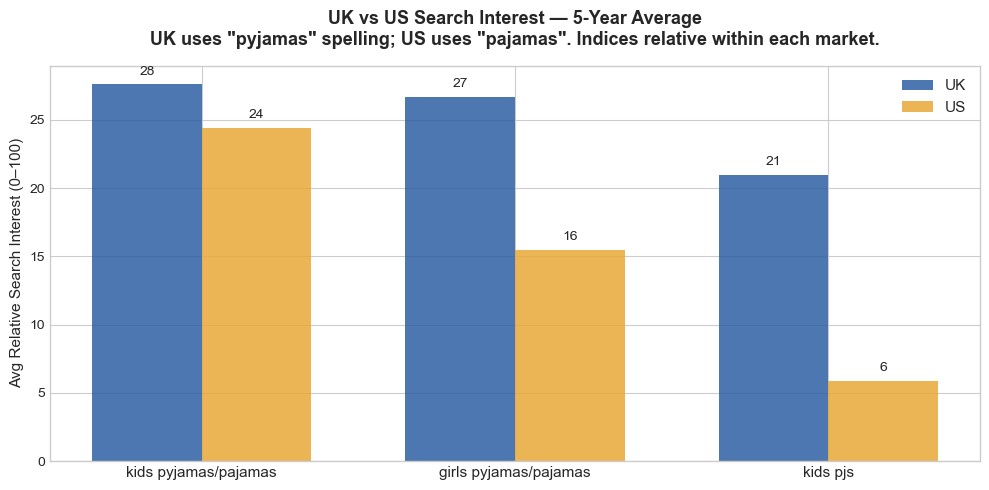

Chart saved.


In [12]:
# ── Chart 3: UK vs US comparison ──────────────────────────────────────────────
# Use overlapping terms only
uk_means = df_uk_final[['kids pyjamas', 'girls pyjamas', 'kids pjs']].mean().rename('UK (pyjamas spelling)')
us_means = df_us_final[['kids pajamas', 'girls pajamas', 'kids pjs']].mean().rename('US (pajamas spelling)')

# Rename index for clean labels
uk_means.index = ['kids pyjamas/pajamas', 'girls pyjamas/pajamas', 'kids pjs']
us_means.index = ['kids pyjamas/pajamas', 'girls pyjamas/pajamas', 'kids pjs']

geo_compare = pd.concat([uk_means, us_means], axis=1).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(geo_compare))
width = 0.35

bars_uk = ax.bar(x - width/2, geo_compare['UK (pyjamas spelling)'], width,
                 label='UK', color=COLOURS['primary'], alpha=0.85)
bars_us = ax.bar(x + width/2, geo_compare['US (pajamas spelling)'], width,
                 label='US', color=COLOURS['secondary'], alpha=0.85)

for bar in list(bars_uk) + list(bars_us):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(geo_compare.index, fontsize=11)
ax.set_ylabel('Avg Relative Search Interest (0–100)', fontsize=11)
ax.set_title('UK vs US Search Interest — 5-Year Average\n'
             'UK uses "pyjamas" spelling; US uses "pajamas". Indices relative within each market.',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.set_ylim(0)

plt.tight_layout()
plt.savefig('/Users/sewabreiler/Desktop/premium-kidswear-market-analysis/reports/summary_visualisations/02_uk_vs_us.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

- Kids pyjamas/pajamas — UK 28 vs US 24, nearly identical. Comparable baseline demand in both markets.
- Girls pyjamas/pajamas — UK 27 vs US 16. UK searches are much more gender-specific — almost as likely to search "girls pyjamas" as "kids pyjamas". US consumers stay more generic.
- Kids pjs — UK 21 vs US 6. The abbreviation is heavily UK-skewed. Americans spell it out more.


The practical implication for a brand entering both markets: UK SEO should optimise equally for kids pyjamas and girls pyjamas. US SEO should lead with kids pajamas and not rely on abbreviations.


**Note on findings: these indices are relative within each market — a 28 in the UK and a 24 in the US don't mean the absolute search volumes are comparable. The US market is roughly 5x the UK population so absolute US volume for kids pajamas at index 24 likely represents far more searches than UK's 28.  Possibly a bullish finding for US expansion — the market is much larger even if the relative index looks similar.

---
## Section 4: Rising Terms — What's Gaining Momentum?

Google Trends 'rising' queries reveal emerging search behaviour — terms that are growing faster than baseline.

In [13]:
# Related queries — top searches associated with core keywords
seed_terms = ['kids pyjamas', 'girls pyjamas', 'kids pajamas', 'kids pjs']
top_results = {}

for term in seed_terms:
    time.sleep(2)
    pytrends.build_payload([term], geo='GB', timeframe='today 5-y')
    related = pytrends.related_queries()
    top = related[term].get('top')
    if top is not None and not top.empty:
        top_results[term] = top.head(8)
        print(f'\nTop queries for "{term}" (UK):')
        print(top.head(8).to_string(index=False))


Top queries for "kids pyjamas" (UK):
                 query  value
christmas kids pyjamas    100
    kids pyjamas girls     51
     kids pyjamas boys     50
       kids pyjamas uk     35
     next kids pyjamas     34
     kids pyjamas sale     22
      m&s kids pyjamas     19
  primark kids pyjamas     17

Top queries for "girls pyjamas" (UK):
                    query  value
       next girls pyjamas    100
       asda girls pyjamas     94
         girls pyjamas uk     67
     george girls pyjamas     53
       girls pyjamas sale     41
    matalan girls pyjamas     38
asda george girls pyjamas     37
    primark girls pyjamas     32

Top queries for "kids pajamas" (UK):
              query  value
           kids pjs    100
 kids pajamas girls     89
  kids pajamas boys     81
  kids pajamas sale     30
grinch kids pajamas     26

Top queries for "kids pjs" (UK):
            query  value
   kids pjs girls    100
    kids pjs boys     89
matching kids pjs     52
    next kids pjs     

- kids pyjamas — Next (34), M&S (19), Primark (17) dominate. All mass market. No premium brand appearing at all.
- girls pyjamas — Next (100), Asda (94), George (53), Matalan (38), Primark (32). Entirely supermarket and high street mass market. 
- kids pjs — matching kids pjs (52) likely parents searching for matching family pyjamas, classic Christmas gifting behaviour.
- kids pajamas — grinch kids pajamas confirms the character/licensed Christmas spike we saw.


**Of Note:** Not a single premium brand appears in any of these top queries. Consumers searching for kids/girls pyjamas in the UK are navigating entirely within the mass market ecosystem — Next, Asda, Primark, Matalan. Premium brands like D&D are found through completely different routes (likely editorial, Instagram, gifting guides) not organic search. This supports the market gap thesis — premium isn't competing on search, it's a different discovery channel entirely.

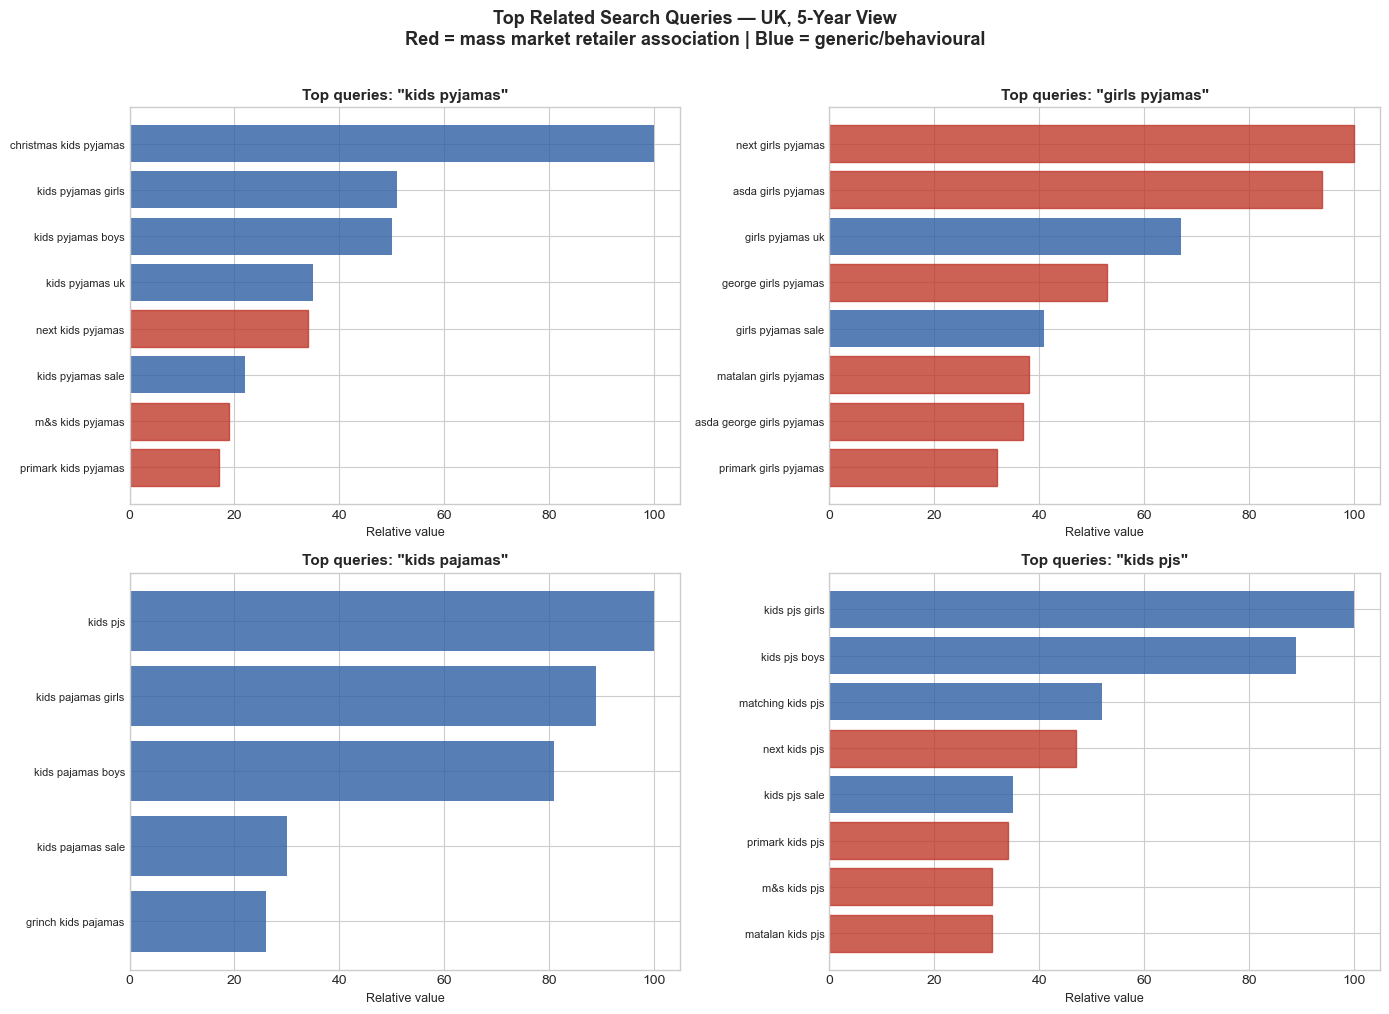

Chart saved.


In [15]:
# ── Chart 4: Top related queries ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (term, df_top) in zip(axes, top_results.items()):
    df_plot = df_top.sort_values('value')
    bars = ax.barh(df_plot['query'], df_plot['value'],
                   color=COLOURS['primary'], alpha=0.8)
    
    # Highlight mass market retailers in a different colour
    mass_market = ['next', 'asda', 'primark', 'matalan', 'george', 'm&s', 'tu']
    for bar, label in zip(bars, df_plot['query']):
        if any(retailer in label.lower() for retailer in mass_market):
            bar.set_color(COLOURS['accent'])
            bar.set_alpha(0.8)
    
    ax.set_xlabel('Relative value', fontsize=9)
    ax.set_title(f'Top queries: "{term}"', fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Top Related Search Queries — UK, 5-Year View\n'
             'Red = mass market retailer association | Blue = generic/behavioural',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('/Users/sewabreiler/Desktop/premium-kidswear-market-analysis/reports/summary_visualisations/02_top_related_queries.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

The red/blue split makes the mass market dominance obvious. girls pyjamas is almost entirely red, (mass market).

- matching kids pjs staying blue — that's a gifting/family behaviour signal, not a retailer. Could be a potential product angle (matching family sets).
- christmas kids pyjamas at 100 being blue — the biggest single search term in the whole dataset is seasonal/gifting, not retailer-driven. Confirms the category is gift-led.
- girls pyjamas uk at 67 blue — people adding "uk" suggests they're looking for UK-specific options, possibly because they're encountering US brands in results and filtering them out. 

---
## Section 5: Brand Search Comparison

How does search interest in the key competitor brands compare? This is a proxy for brand awareness and consumer mindshare.

In [23]:
# Brand name searches — UK, 5 year
# Note: without 'pyjamas'
brand_terms = [
    'Desmond Dempsey',
    'Roller Rabbit',
    'Pink Chicken',
    'White Fox',
]

print('Fetching brand search data (UK)...')
df_brands_uk = get_trends(brand_terms, geo='GB', timeframe='today 5-y')

print('\nAverage UK brand search interest:')
print(df_brands_uk.mean().sort_values(ascending=False).round(1).to_string())

Fetching brand search data (UK)...

Average UK brand search interest:
White Fox          19.9
Pink Chicken        1.6
Desmond Dempsey     0.2
Roller Rabbit       0.0


In [24]:
# Brand name searches — UK, 5 year
# Note: with 'pyjamas'
brand_terms = [
    'Desmond Dempsey',
    'Roller Rabbit',
    'Pink Chicken',
    'White Fox',
]

print('Fetching brand search data (UK)...')
df_brands_uk = get_trends(brand_terms, geo='GB', timeframe='today 5-y')

print('\nAverage UK brand search interest:')
print(df_brands_uk.mean().sort_values(ascending=False).round(1).to_string())

Fetching brand search data (UK)...

Average UK brand search interest:
White Fox          19.9
Pink Chicken        1.6
Desmond Dempsey     0.2
Roller Rabbit       0.0


**Key Findings:** The premium pyjama brands with the most beautiful products have near-zero Google search presence. They live on Instagram and in Sunday Times Style gift guides, not on Google. This means a new entrant in this space needs a social-first discovery strategy, not an SEO-first one. Google search is the mass market channel (Next, Primark, M&S). Premium is found differently.

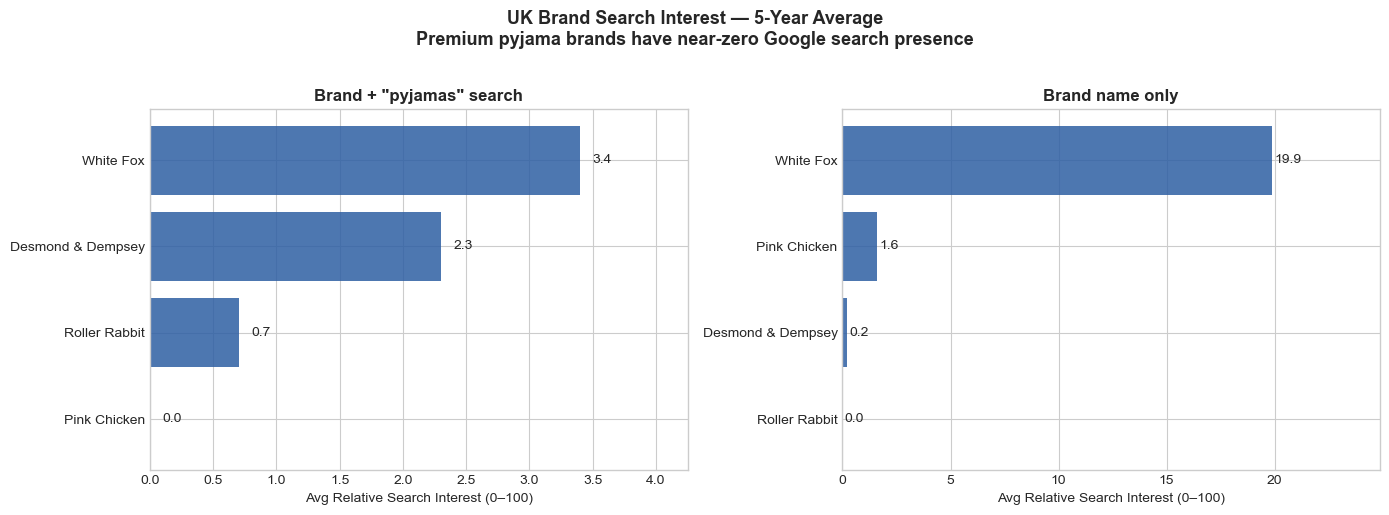

Chart saved.


In [25]:
# ── Chart 5: Brand search comparison ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# With pyjamas
brand_with = pd.Series({
    'White Fox': 3.4,
    'Desmond & Dempsey': 2.3,
    'Roller Rabbit': 0.7,
    'Pink Chicken': 0.0
}).sort_values()

# Without pyjamas  
brand_without = pd.Series({
    'White Fox': 19.9,
    'Pink Chicken': 1.6,
    'Desmond & Dempsey': 0.2,
    'Roller Rabbit': 0.0
}).sort_values()

for ax, data, title in zip(axes,
    [brand_with, brand_without],
    ['Brand + "pyjamas" search', 'Brand name only']):
    
    bars = ax.barh(data.index, data.values, color=COLOURS['primary'], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1f}', va='center', fontsize=10)
    ax.set_xlabel('Avg Relative Search Interest (0–100)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, max(data.values) * 1.25)

fig.suptitle('UK Brand Search Interest — 5-Year Average\n'
             'Premium pyjama brands have near-zero Google search presence',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('/Users/sewabreiler/Desktop/premium-kidswear-market-analysis/reports/summary_visualisations/02_brand_search.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

### Methodology Note — Brand Search Comparison

Google Trends indexes all terms within a single query relative to each other 
(highest term = 100, others scaled proportionally). This means the absolute 
numbers shift depending on which brands are compared together.

Two approaches used here:
- **Brand + "pyjamas"** — isolates pyjama-specific search intent. All four 
  brands return near-zero, confirming premium pyjama brands are not discovered 
  via Google search.
- **Brand name only** — captures general brand awareness. White Fox dominates 
  due to social media-driven growth; D&D and Roller Rabbit remain near-zero 
  confirming they rely entirely on editorial and word-of-mouth for discovery.

**Implication:** A new entrant in premium kids/teen loungewear should not 
prioritise SEO as a primary acquisition channel. Discovery happens through 
Instagram, editorial (Sunday Times Style, gifting guides), and word of mouth — 
not Google search. Mass market brands (Next, M&S, Primark) own the search channel.

---
## Section 6: Key Findings

In [33]:
print('=' * 65)
print('GOOGLE TRENDS ANALYSIS — KEY FINDINGS')
print('=' * 65)

# 1. Seasonality — calculated from data
peak_month = monthly_avg.mean(axis=1).idxmax()
trough_month = monthly_avg.mean(axis=1).idxmin()
peak_val = monthly_avg.mean(axis=1).max()
trough_val = monthly_avg.mean(axis=1).min()
uplift = ((peak_val / trough_val) - 1) * 100

print()
print('1. SEASONALITY')
print(f'   Peak month: {peak_month} (avg interest: {peak_val:.0f})')
print(f'   Trough month: {trough_month} (avg interest: {trough_val:.0f})')
print(f'   Seasonal uplift: {uplift:.0f}% peak vs trough')
print('   Implication: stock and marketing must be in place by October')
print('   Christmas gifting drives the category — "christmas kids pyjamas"')
print('   was the single highest-indexed search term in the dataset')

# 2. Trend direction — calculated from data
first_half = df_uk_final['kids pyjamas'].iloc[:len(df_uk_final)//2].mean()
second_half = df_uk_final['kids pyjamas'].iloc[len(df_uk_final)//2:].mean()
direction = 'growing' if second_half > first_half else 'declining'
change = ((second_half / first_half) - 1) * 100

print()
print('2. TREND DIRECTION')
print(f'   "kids pyjamas" UK: {direction} ({change:+.0f}% second half vs first half of 5yr period)')
print(f'   "girls pyjamas" tracks almost identically to "kids pyjamas"')
print(f'   — gender-specific search is as common as the generic term')

print()
print('3. SEARCH LANGUAGE')
print('   Consumers use "pyjamas" not "nightwear" or "loungewear"')
print('   "kids pjs" (21.0) is heavily used — abbreviation matters for SEO')
print('   "tween", "loungewear", "nightwear" all returned near-zero — dropped')
print('   US market uses "pajamas" spelling — separate SEO strategy required')
print('   "matching kids pjs" signals family gifting behaviour')

print()
print('4. UK vs US')
uk_kids = df_uk_final['kids pyjamas'].mean()
us_kids = df_us_final['kids pajamas'].mean()
print(f'   UK "kids pyjamas": {uk_kids:.1f} | US "kids pajamas": {us_kids:.1f}')
print('   Comparable relative demand — but US population ~5x UK')
print('   Absolute US search volume likely 4-5x UK for equivalent terms')
print('   Bullish signal for US expansion potential')

print()
print('5. BRAND DISCOVERY')
print('   No premium brand appears in top related queries for any pyjama term')
print('   Mass market retailers dominate search: Next, Asda, Primark, Matalan')
print('   Premium brands (D&D, Roller Rabbit) have near-zero Google presence')
print('   Implication: premium discovery happens via Instagram, editorial,')
print('   gifting guides — not Google. SEO is not the primary channel.')

print()
print('=' * 65)

GOOGLE TRENDS ANALYSIS — KEY FINDINGS

1. SEASONALITY
   Peak month: Nov (avg interest: 49)
   Trough month: Jun (avg interest: 9)
   Seasonal uplift: 471% peak vs trough
   Implication: stock and marketing must be in place by October
   Christmas gifting drives the category — "christmas kids pyjamas"
   was the single highest-indexed search term in the dataset

2. TREND DIRECTION
   "kids pyjamas" UK: growing (+41% second half vs first half of 5yr period)
   "girls pyjamas" tracks almost identically to "kids pyjamas"
   — gender-specific search is as common as the generic term

3. SEARCH LANGUAGE
   Consumers use "pyjamas" not "nightwear" or "loungewear"
   "kids pjs" (21.0) is heavily used — abbreviation matters for SEO
   "tween", "loungewear", "nightwear" all returned near-zero — dropped
   US market uses "pajamas" spelling — separate SEO strategy required
   "matching kids pjs" signals family gifting behaviour

4. UK vs US
   UK "kids pyjamas": 27.6 | US "kids pajamas": 24.4
   Co